# Rozwiązanie qubo plus gnn
spróbujemy dla małego przykładu a później dla większego rozwiązać problem przypisania

Na początku spróbuję wytłumaczyć jak dane elementy problemu przetworzę do postaci dla qubo a potem zapiszemy to w python.

## Funkcja Celu
Dla tego przykładu funkcja celu:
$$
\min \left( \sum_{i \in L} \sum_{n \in M} r_{in} \cdot x_{in} + \sum_{i \in L}  c_i \cdot y_{i} \right)
$$




Gdybyśmy zapomnieli o naszych ograniczeniach to macierz Q by wyglądała teraz tak wiedząc że
zmienne liniowe możemy zapisać jako kwadratowe
$$
x_j = x_j^2
$$

wzór qubo:
$$
\min y = x^T Q x
$$
Przykładowa macierz Q może wyglądać:
Q =
|       | x₁₁   | x₁₂   | x₂₁   | x₂₂   | x₃₁   | x₃₂   |
|-------|--------|--------|--------|--------|--------|--------|
| x₁₁  | 47.31  | 0      | 0      | 0      | 0      | 0      |
| x₁₂  | 0      | 7002   | 0      | 0      | 0      | 0      |
| x₂₁  | 0      | 0      | 492    | 0      | 0      | 0      |
| x₂₂  | 0      | 0      | 0      | 4304      | 0   | 0      |
| x₃₁  | 0      | 0      | 0      | 0      | 1000      | 0   |
| x₃₂  | 0      | 0      | 0      | 0      | 0      | 6100   |









## Ograniczenia
W problemie występują dane ograniczenia

$$
\sum_{i \in L}  x_{i,n} = 1 \quad \forall n \in M
$$

$$
 \sum_{n \in M} x_{i,n} \leq v_i \quad \forall i \in L
$$

$$
 \sum_{i \in L} c_i \cdot y_{i} \leq p
$$

$$
x_{in} \leq y_i   \   \quad \forall i \in L \ \forall n \in M
$$


Aby przekształcić ogranicznia możemy skorzystać z przekształceń w kary które wyglądają tak:
| Klasyczne Ograniczenie          | Odpowiadająca kara                          |
|-------------------------------|---------------------------------------------|
|  x + y <= 1             | P(xy)                                  |
|  x + y >= 1             |  P(1 - x - y + xy)                      |
|  x + y = 1               |  P(1 - x - y + 2xy)                     |
| x <= y               |  P(x - xy)                            |
|  x_1 + x_2 + x_3 <= 1  | P(x_1x_2 + x_1x_3 + x_2x_3)           |
|  x = y                   | P(x + y - 2xy)                         |

Zaś jeśli są nierówności to możemy skorzystać z tzw. *slack variables*:

Przykład z nimi:

$$
3x_0 + 11x_1 + 14x_2 + 19x_3 + 5x_4 \le 26
$$

$$
3x_0 + 11x_1 + 14x_2 + 19x_3 + 5x_4 + S_1 = 26 \tag{4}
$$

gdzie:
$$
S = \sum_{k=0}^{N-1} 2^k s_k,
$$

$$
N = \lfloor\log_2(\max S)\rfloor + 1.
$$


czyli:
$$
S_1 = 2^0 s_{01} + 2^1 s_{11} + 2^2 s_{21} + 2^3 s_{31} + 2^4 s_{41}
$$

Funkcja kary:
$$
p(x,s) = \lambda \left(3x_0 + 11x_1 + 14x_2 + 19 x_3 + 5x_4 + x_5 + 2 x_6 + 4x_7 + 8 x_8 + 16 x_9 - 26\right)^2 \tag{5}
$$


### A więc dla ograniczenia #1:
$$ \sum_{i \in L} x_{i,n} = 1 \quad \forall n \in M $$
- Każdy obiekt $n$ musi być przypisany do dokładnie jednego schronu $i$

Które możemy rozpisać jako:
$$ x_{11} + x_{21} + x_{31} = 1 $$
$$ x_{12} + x_{22} + x_{32} = 1 $$

Zapisujemy jako karę: (czemu akurat taka kara ? strona 28 opisująca qubo)
$$ P_1*(x_{11} + x_{21} + x_{31} - 1)^2 + P_1*(x_{12} + x_{22} + x_{32} - 1)^2 $$




### Ograniczenie #2:
$$
\sum_{n \in M} x_{in} \leq v_i \quad \forall i \in L
$$
- Schron $i$ może obsłużyć tylko tyle obiektów mieszkalnych $n$ ile wynosi jego pojemność $v_{i}$

Które możemy rozpisać jako:
$$
(x_{11} + x_{12}) \leq 2
$$

$$
(x_{21}  + x_{22}) \leq 1
$$

$$
(x_{31} + x_{32}) \leq 1
$$
Stosujemy slack variable i zapisujemy:
$$
    (x_{11} + x_{12}  + S_{1}) = 2
$$
$$
    (x_{21} + x_{22} + S_{2}) = 1
$$
$$
    (x_{31} + x_{32} + S_{3}) = 1
$$
gdzie dla każdego S:
$$
S = \sum_{k=0}^{N-1} 2^k s_k,
$$
$$Dla S_{1} N=2  $$
$$ S_{1}:
P_2*(x_{11} + x_{12} + s_{10} + 2*s_{11}  - 2)^2
$$







### Ograniczenie #3:
$$
\sum_{i \in L} c_i \cdot y_{i} \leq p
$$

Rozpisujemy analogicznie jak przypadki powyżej

### Ograniczenie #4:
$$
x_{in} \leq y_i   \   \quad \forall i \in L \ \forall n \in M
$$
- Możemy przypisać obiekt mieszkalny $n$ do schronu $i$ gdy wybudujemy schron




## Zapisanie Qubo Python


## przykładowe dane

In [1]:
import pandas as pd
from geopy.distance import geodesic # do obliczenia odległości
import numpy as np
import math

s = 2 # dostępne lokalizacje nowe
e = 1 # istniejace juz schrony
h = 2 # liczba obiektów mieszkalnych

P = [40, 4, 4, 40]  # kara (do dostosowania póki co losowe)

c = [2, 2, 0] # Koszty wybudowania schronu i ostatni jest za darmo ponieważ już istnieje

p = 4 # budżet na schrony
v = [2, 1, 1] # Pojemność schronu i - działa to tak że możemy w danym schronie mieć ileś

slack_sizes = [math.floor(math.log2(vi))  for vi in v] # za pojemności schronów
slack_sizes.append(math.floor(math.log2(p)) ) # za budżet

# Lokalizacje schrony i
L = [[51.103504, 17.086370],
    [51.100217, 17.082551],
    [51.100390, 17.099490]]

# Lokalizacje obiekty mieszkalne n
M = [[51.103910, 17.086310],
    [51.105504, 17.186370]]

# Odległości r_{i,n} w kilometrach
r = [[geodesic(l, m).kilometers for m in M] for l in L]
r = np.array(r)

# Zmienna decyzyjna jeśli schron
x = [[1 for _ in range(h)] for _ in range(s + e)]

# Inicjalizacja QUBO - bierzemy pod uwagę już zmiennę typu slack
N = (s + e) * h + (s + e) + sum(slack_sizes)
Q = np.zeros((N, N))

def idx_x(i, n):
    return i * h + n

def idx_y(i):
    return (s+e)*h + i
Q

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Funkcja celu: $$
\min \left( \sum_{i \in L} \sum_{n \in M} r_{in} \cdot x_{in} + \sum_{i \in L}  c_i \cdot y_{i} \right)
$$

In [2]:
# koszty odległości dla x_{i,n}
for i in range(s + e):
    for n in range(h):
        Q[idx_x(i, n), idx_x(i, n)] += r[i][n]

# koszty budowy dla y_i
for i in range(s + e):
    Q[idx_y(i), idx_y(i)] += c[i]
Q

array([[0.04536269, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 7.00751965, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.48797431, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 7.29547536, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 1.0027953 ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        6.11180586, 0.        , 0.        , 0.        , 0.        ,
        0.        ,

Ograniczenia:
$$
\sum_{i \in L} x_{i,n} = 1 \quad \forall n \in M
$$

In [3]:
for n in range(h):
    terms = [(idx_x(i, n), 1) for i in range(s + e)]

    # przekątna
    for a, wa in terms:
        Q[a, a] += P[0] * wa**2 - 2 * P[0] * wa

     # pary zmiennych
    for i in range(len(terms)):
        for j in range(i + 1, len(terms)):
            a, wa = terms[i]
            b, wb = terms[j]
            value = 2* P[0] * wa * wb
            Q[a, b] += value / 2
            Q[b, a] += value / 2
Q

array([[-39.95463731,   0.        ,  40.        ,   0.        ,
         40.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        , -32.99248035,   0.        ,  40.        ,
          0.        ,  40.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ 40.        ,   0.        , -39.51202569,   0.        ,
         40.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,  40.        ,   0.        , -32.70452464,
          0.        ,  40.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ 40.        ,   0.        ,  40.        ,   0.        ,
        -38.9972047 ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,  40.        ,

$$
 \sum_{n \in M} x_{i,n} \leq v_i \quad \forall i \in L
$$

In [4]:
slack_offset = (s + e) * h

for i in range(s + e):
    N_i = math.floor(math.log2(v[i])) + 1
    slack_idxs = [slack_offset + sum(slack_sizes[:i]) + k for k in range(N_i)]

    x_terms = [(idx_x(i, n), 1) for n in range(h)]
    s_terms = [(s_idx, 2**k) for k, s_idx in enumerate(slack_idxs)]

    terms = x_terms + s_terms
    rhs = v[i]

    for a, wa in terms:
        Q[a, a] += P[1] * (wa ** 2) - 2 * P[1] * rhs * wa
        for b, wb in terms:
            if a < b:
                Q[a, b] += P[1] * wa * wb
                Q[b, a] += P[1] * wa * wb
Q

array([[-51.95463731,   4.        ,  40.        ,   0.        ,
         40.        ,   0.        ,   4.        ,   8.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  4.        , -44.99248035,   0.        ,  40.        ,
          0.        ,  40.        ,   4.        ,   8.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ 40.        ,   0.        , -43.51202569,   4.        ,
         40.        ,   0.        ,   0.        ,   4.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,  40.        ,   4.        , -36.70452464,
          0.        ,  40.        ,   0.        ,   4.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ 40.        ,   0.        ,  40.        ,   0.        ,
        -42.9972047 ,   4.        ,   0.        ,   4.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,  40.        ,

$$
\sum_{i \in L} c_i \cdot y_{i} \leq p
$$

In [5]:
slack_offset = (s + e) * h  # po x'ach
y_offset = slack_offset + sum(slack_sizes[:-1])  # po wszystkich slackach pojemnościowych
budget_slack_offset = y_offset + (s + e)  # po y'ach
budget_slack_bits = slack_sizes[-1]

rhs = p

# y_i z wagami c_i
terms_y = [(y_offset + i, c[i]) for i in range(s + e)]
# slack bity dla budżetu
terms_s = [(budget_slack_offset + k, 2 ** k) for k in range(budget_slack_bits)]

terms = terms_y + terms_s

for a, wa in terms:
    Q[a, a] += P[2] * (wa ** 2) - 2 * P[2] * wa * rhs
    for b, wb in terms:
        if a < b:
            Q[a, b] += P[2] * wa * wb
Q

array([[-51.95463731,   4.        ,  40.        ,   0.        ,
         40.        ,   0.        ,   4.        ,   8.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  4.        , -44.99248035,   0.        ,  40.        ,
          0.        ,  40.        ,   4.        ,   8.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ 40.        ,   0.        , -43.51202569,   4.        ,
         40.        ,   0.        ,   0.        ,   4.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,  40.        ,   4.        , -36.70452464,
          0.        ,  40.        ,   0.        ,   4.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ 40.        ,   0.        ,  40.        ,   0.        ,
        -42.9972047 ,   4.        ,   0.        ,   4.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,  40.        ,

$$
x_{in} \leq y_i   \   \quad \forall i \in L \ \forall n \in M
$$

In [6]:
for i in range(s + e):
    for n in range(h):
        x_idx = idx_x(i, n)
        y_idx = y_offset + i

        Q[x_idx, x_idx] += P[3]
        Q[x_idx, y_idx] += -P[3]
        Q[y_idx, x_idx] += -P[3]
Q

array([[-11.95463731,   4.        ,  40.        ,   0.        ,
         40.        ,   0.        ,   4.        , -32.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  4.        ,  -4.99248035,   0.        ,  40.        ,
          0.        ,  40.        ,   4.        , -32.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ 40.        ,   0.        ,  -3.51202569,   4.        ,
         40.        ,   0.        ,   0.        ,   4.        ,
        -40.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,  40.        ,   4.        ,   3.29547536,
          0.        ,  40.        ,   0.        ,   4.        ,
        -40.        ,   0.        ,   0.        ,   0.        ],
       [ 40.        ,   0.        ,  40.        ,   0.        ,
         -2.9972047 ,   4.        ,   0.        ,   4.        ,
          0.        , -40.        ,   0.        ,   0.        ],
       [  0.        ,  40.        ,

## Wpisanie do sieci grafowej

## Budowa grafu

In [7]:
import torch
from torch_geometric.data import Data
import numpy as np

Q_sparse = (Q != 0)
rows, cols = np.where(Q_sparse)

edge_index = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
edge_attr = torch.tensor(Q[rows, cols], dtype=torch.float)

x = torch.ones((N, 1), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [8]:
data

Data(x=[12, 1], edge_index=[2, 61], edge_attr=[61])

### Jak to wygląda ?

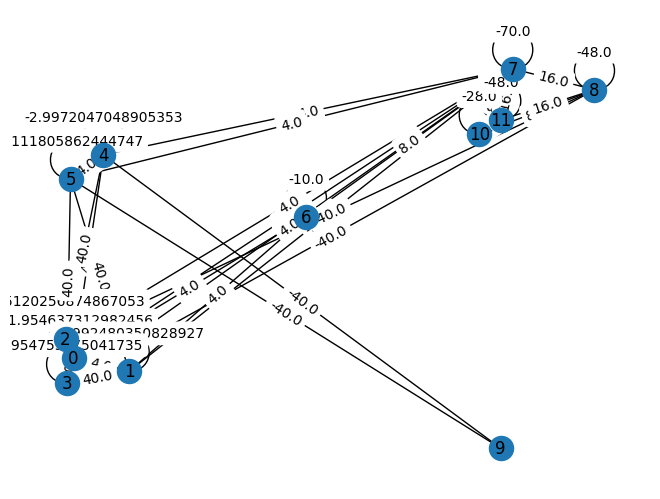

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from(range(N))
rows, cols = np.where(Q_sparse)
for i, j in zip(rows, cols):
    G.add_edge(i, j, weight=Q[i, j])


pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=300)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch.optim import Adam

class QUBOGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.001):
        super().__init__()
        # wyłącz automatyczne self-loops i normalizację, jeśli wolisz kontrolować normalizację samemu
        self.conv1 = GCNConv(in_channels, hidden_channels, add_self_loops=False, normalize=False)
        self.conv2 = GCNConv(hidden_channels, out_channels, add_self_loops=False, normalize=False)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_attr
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return torch.sigmoid(x).squeeze()

In [11]:
def qubo_loss(probs, Q):
    probs = probs.view(-1, 1)  # (N, 1)
    Q = Q.detach().float().to(probs.device)
    return (probs.T @ Q @ probs).squeeze()

In [12]:
def train_qubo_gnn(data, Q, model, optimizer, epochs=1000, tol=1e-4, patience=10000, threshold=0.5):
    best_loss = float('inf')
    best_solution = None
    wait = 0

    if not isinstance(Q, torch.Tensor):
        Q = torch.tensor(Q, dtype=torch.float32)
    Q = Q.detach().to(model.parameters().__next__().device)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        probs = model(data)
        loss = qubo_loss(probs, Q)
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
            print(f"Probs: {probs}")

        # Early stopping
        if loss.item() + tol < best_loss:
            best_loss = loss.item()
            best_solution = (probs >= threshold).float().detach()
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    return best_solution, best_loss

In [13]:
in_channels = 1
hidden_channels = 32
out_channels = 1
dropout = 0.01
learning_rate = 1e-3
epochs = 5000
tolerance = 1e-4
patience = 5000
threshold = 0.9

model = QUBOGCN(in_channels, hidden_channels, out_channels, dropout)
model = model.to(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# trening
best_solution, best_loss = train_qubo_gnn(
    data=data,
    Q=Q,
    model=model,
    optimizer=optimizer,
    epochs=epochs,
    tol=tolerance,
    patience=patience,
    threshold=threshold
)


bitlist = best_solution.int().cpu().tolist()
print(f"Najlepsze rozwiązanie {bitlist}")

objective = 0.0
for i in range(s+e):
    y_i = bitlist[y_offset + i]
    objective += c[i] * y_i  # koszt budowy

    for n in range(h):
        x_in = bitlist[idx_x(i, n)]
        objective += r[i][n] * x_in  # koszt odległości

print(f"Najlepsza wartość funkcji celu (QUBO): {best_loss:.4f}")
print(f"Wartość funkcji celu: {objective}")

print("\nRozwiązanie")
for i in range(s+e):
    y_i = bitlist[y_offset + i]
    status = "BUDOWANY" if y_i == 1 else "NIE budowany"
    print(f"Schron {i}: {status}")
    for n in range(h):
        if bitlist[idx_x(i, n)] == 1:
            print(f"  -> przydzielony mieszkaniec {n}")

C:\Users\jakub\AppData\Roaming\Python\Python310\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0, Loss: 127.950928
Probs: tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
Epoch 100, Loss: 127.950928
Probs: tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
Epoch 200, Loss: 127.950928
Probs: tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
Epoch 300, Loss: 127.950928
Probs: tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
Epoch 400, Loss: 127.950928
Probs: tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
Epoch 500, Loss: 127.950928
Probs: tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
Epoch 600, Loss: 127.950928
Probs: tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.], device='cuda:0',
       grad_fn=<SqueezeBackwa

# Rozwiązanie z dużą ilością danych

In [15]:
import pandas as pd

# wczytanie danych
data = pd.read_csv("data/schrony-csv.csv")

# Filtruj do schronów we Wrocławiu w określonym prostokącie
data = data[
    (data["County"] == "Wrocław") &
    ( (data["FacilityType"] == "[1] - (S) - schron") | (data["FacilityType"] == "[2] - (U) - ukrycie")) &
    (data["y"] >= 51.101153) & (data["y"] <= 51.127456) &  # latitude
    (data["x"] >= 17.068503) & (data["x"] <= 17.123730)    # longitude
].dropna()
data

,ObjectID,InventoryType,AccessedBy,Area,Capacity,SubjectiveEvaluation,FacilityType,Purpose,Voivodeship,County,Address,x,y
15179,183746,[2] - Rozpoznanie z urzędnikiem,[2] - inna droga utwardzona,122,81,1,[1] - (S) - schron,[1] - M,DOLNOŚLĄSKIE,Wrocław,"ulica Adama Mickiewicza 49, 51-684, Wrocław, Dolnośląskie, POL",17.094320,51.113365
15182,184889,[2] - Rozpoznanie z urzędnikiem,[2] - inna droga utwardzona,67,44,1,[1] - (S) - schron,[1] - M,DOLNOŚLĄSKIE,Wrocław,"ulica Marcina Borelowskiego 2-4, 51-678, Wrocław, Dolnośląskie, POL",17.103514,51.108523
15195,203568,[2] - Rozpoznanie z urzędnikiem,[1] - droga pożarowa,200,133,2,[1] - (S) - schron,[2] - Z,DOLNOŚLĄSKIE,Wrocław,"ulica Kwidzyńska 6, 51-416, Wrocław, Dolnośląskie, POL",17.097481,51.127363
17216,242725,[2] - Rozpoznanie z urzędnikiem,[3] - droga nieutwardzona,50,33,1,[1] - (S) - schron,[2] - Z,DOLNOŚLĄSKIE,Wrocław,"ulica Monopolowa 6, 51-501, Wrocław, Dolnośląskie, POL",17.103889,51.122050
17217,242732,[2] - Rozpoznanie z urzędnikiem,[3] - droga nieutwardzona,15,10,1,[2] - (U) - ukrycie,[2] - Z,DOLNOŚLĄSKIE,Wrocław,"ulica Monopolowa 6, 51-501, Wrocław, Dolnośląskie, POL",17.103902,51.122040
17218,242738,[2] - Rozpoznanie z urzędnikiem,[3] - droga nieutwardzona,35,23,1,[2] - (U) - ukrycie,[2] - Z,DOLNOŚLĄSKIE,Wrocław,"ulica Monopolowa 6, 51-501, Wrocław, Woj. Dolnośląskie, POL",17.105234,51.123316


In [16]:
import pandas as pd
from geopy.distance import geodesic
import numpy as np
import math

s = 6
h = 50
p = 15
P = [100, 10, 10, 100]
e = len(data)

L_new = [
    [51.103504, 17.086370],
    [51.100217, 17.082551],
    [51.100390, 17.099490],
    [51.100590, 17.0590],
    [51.100190, 17.079490],
    [51.100590, 17.059490]
]

L_existing = data[["y", "x"]].values.tolist()

L = L_new + L_existing

# Koszty i pojemności
c = [2, 2, 4, 6, 8, 1] + [0]*e
v = [10, 4, 1, 5, 6, 4] + list(data["Capacity"] / 10)

slack_sizes = [math.floor(math.log2(vi))  for vi in v] # za pojemności schronów
slack_sizes.append(math.floor(math.log2(p)) ) # za budżet

# losowanie obiektów mieszkalnych
np.random.seed(42)
lat_range = (51.101153, 51.127456)
lon_range = (17.068503, 17.123730)
M = [
    [np.random.uniform(*lat_range), np.random.uniform(*lon_range)]
    for _ in range(h)
]

# Odległości r_{i,n} w kilometrach
r = [[geodesic(l, m).kilometers for m in M] for l in L]
r = np.array(r)

# Zmienna decyzyjna jeśli schron
x = [[1 for _ in range(h)] for _ in range(s + e)]

# Inicjalizacja QUBO - bierzemy pod uwagę już zmiennę typu slack
N = (s + e) * h + (s + e) + sum(slack_sizes)
Q = np.zeros((N, N))

def idx_x(i, n):
    return i * h + n

def idx_y(i):
    return (s+e)*h + i
Q

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [17]:
# \min \left( \sum_{i \in L} \sum_{n \in M} r_{in} \cdot x_{in} + \sum_{i \in L}  c_i \cdot y_{i} \right)
# koszty odległości dla x_{i,n}
for i in range(s + e):
    for n in range(h):
        Q[idx_x(i, n), idx_x(i, n)] += r[i][n]

# koszty budowy dla y_i
for i in range(s + e):
    Q[idx_y(i), idx_y(i)] += c[i]

#\sum_{i \in L} x_{i,n} = 1 \quad \forall n \in M

for n in range(h):
    terms = [(idx_x(i, n), 1) for i in range(s + e)]

    # przekątna
    for a, wa in terms:
        Q[a, a] += P[0] * wa**2 - 2 * P[0] * wa

     # pary zmiennych
    for i in range(len(terms)):
        for j in range(i + 1, len(terms)):
            a, wa = terms[i]
            b, wb = terms[j]
            value = 2* P[0] * wa * wb
            Q[a, b] += value / 2
            Q[b, a] += value / 2

# \sum_{n \in M} x_{i,n} \leq v_i \quad \forall i \in L
slack_offset = (s + e) * h

for i in range(s + e):
    N_i = math.floor(math.log2(v[i])) + 1
    slack_idxs = [slack_offset + sum(slack_sizes[:i]) + k for k in range(N_i)]

    x_terms = [(idx_x(i, n), 1) for n in range(h)]
    s_terms = [(s_idx, 2**k) for k, s_idx in enumerate(slack_idxs)]

    terms = x_terms + s_terms
    rhs = v[i]

    for a, wa in terms:
        Q[a, a] += P[1] * (wa ** 2) - 2 * P[1] * rhs * wa
        for b, wb in terms:
            if a < b:
                Q[a, b] += P[1] * wa * wb
                Q[b, a] += P[1] * wa * wb

# \sum_{i \in L} c_i \cdot y_{i} \leq p
slack_offset = (s + e) * h  # po x'ach
y_offset = slack_offset + sum(slack_sizes[:-1])  # po wszystkich slackach pojemnościowych
budget_slack_offset = y_offset + (s + e)  # po y'ach
budget_slack_bits = slack_sizes[-1]

rhs = p

# y_i z wagami c_i
terms_y = [(y_offset + i, c[i]) for i in range(s + e)]
# slack bity dla budżetu
terms_s = [(budget_slack_offset + k, 2 ** k) for k in range(budget_slack_bits)]

terms = terms_y + terms_s

for a, wa in terms:
    Q[a, a] += P[2] * (wa ** 2) - 2 * P[2] * wa * rhs
    for b, wb in terms:
        if a < b:
            Q[a, b] += P[2] * wa * wb
# x_{in} \leq y_i   \   \quad \forall i \in L \ \forall n \in M
for i in range(s + e):
    for n in range(h):
        x_idx = idx_x(i, n)
        y_idx = y_offset + i

        Q[x_idx, x_idx] += P[3]
        Q[x_idx, y_idx] += -P[3]
        Q[y_idx, x_idx] += -P[3]

In [18]:
Q_sparse = (Q != 0)
rows, cols = np.where(Q_sparse)

edge_index = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
edge_attr = torch.tensor(Q[rows, cols], dtype=torch.float)

x = torch.ones((N, 1), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [19]:
in_channels = 1
hidden_channels = 32
out_channels = 1
dropout = 0.01
learning_rate = 1e-3
epochs = 5000
tolerance = 1e-4
patience = 1000
threshold = 0.9

model = QUBOGCN(in_channels, hidden_channels, out_channels, dropout)
model = model.to(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# trening
best_solution, best_loss = train_qubo_gnn(
    data=data,
    Q=Q,
    model=model,
    optimizer=optimizer,
    epochs=epochs,
    tol=tolerance,
    patience=patience,
    threshold=threshold
)


bitlist = best_solution.int().cpu().tolist()
print(f"Najlepsze rozwiązanie {bitlist}")

objective = 0.0
for i in range(s+e):
    y_i = bitlist[y_offset + i]
    objective += c[i] * y_i  # koszt budowy

    for n in range(h):
        x_in = bitlist[idx_x(i, n)]
        objective += r[i][n] * x_in  # koszt odległości

print(f"Najlepsza wartość funkcji celu (QUBO): {best_loss:.4f}")
print(f"Wartość funkcji celu: {objective}")

print("\nRozwiązanie")
for i in range(s+e):
    y_i = bitlist[y_offset + i]
    status = "BUDOWANY" if y_i == 1 else "NIE budowany"
    print(f"Schron {i}: {status}")
    for n in range(h):
        if bitlist[idx_x(i, n)] == 1:
            print(f"  -> przydzielony obiekt {n}")

Epoch 0, Loss: 979403.875000
Probs: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
    

Jak widać nie udało mi się dobrać odpowiedniej wagi kar przez co model ignoruje ograniczenia co aktualnie badam,